In [392]:
#Sales performance project
#loading the data 
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Set number of records
n_records = 5000

# Helper function to generate fake-like data without Faker
def random_phone():
    return f"{random.randint(100, 999)}-{random.randint(100, 999)}-{random.randint(1000, 9999)}"

def random_email():
    names = ['john', 'jane', 'mike', 'sarah', 'david', 'lisa', 'alex', 'emma']
    domains = ['gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com']
    return f"{random.choice(names)}{random.randint(1, 999)}@{random.choice(domains)}"

def random_address():
    streets = ['Main St', 'Oak Ave', 'Pine Rd', 'Maple Ln', 'Cedar Blvd']
    return f"{random.randint(1, 9999)} {random.choice(streets)}"

def random_city():
    cities = ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix', 'Philadelphia', 'San Antonio', 'San Diego']
    return random.choice(cities)

def random_state():
    states = ['CA', 'TX', 'NY', 'FL', 'IL', 'PA', 'OH', 'GA', 'NC', 'MI']
    return random.choice(states)

def random_zip():
    return f"{random.randint(10000, 99999)}"

def random_date(start_year=-2):
    start_date = datetime.now() + timedelta(days=random.randint(-730, 0))
    return start_date.date()

# Generate messy data
data = {
    # Customer Information
    'customer_id': list(range(1001, 1001 + n_records)),
    'gender': [random.choice(['M', 'F', 'Male', 'Female', 'm', 'f', 'MALE', 'FEMALE', np.nan, 'U', 'Unknown']) 
               for _ in range(n_records)],
    'age': [random.choice([random.randint(15, 90), np.nan, 'thirty', '25', '40+', '18-25', None, 105]) 
            for _ in range(n_records)],
    'email': [random_email() if random.random() > 0.1 else 'invalid_email' for _ in range(n_records)],
    'phone_number': [random_phone() if random.random() > 0.15 else '123-456-7890' for _ in range(n_records)],
    'address': [random_address() if random.random() > 0.05 else 'Unknown' for _ in range(n_records)],
    'city': [random_city() if random.random() > 0.08 else 'New Yrok' for _ in range(n_records)],
    'state': [random_state() if random.random() > 0.08 else 'CA' for _ in range(n_records)],
    'zip_code': [random_zip() if random.random() > 0.1 else '00000' for _ in range(n_records)],
    'residence_type': [random.choice(['Own', 'Rent', 'Lease', 'OWN', 'rent', np.nan, 'Other', 'With Parents']) 
                       for _ in range(n_records)],
    
    # Transaction Information
    'transaction_id': [f'TXN{str(i).zfill(6)}' for i in range(1, n_records + 1)],
    'transaction_date': [random_date() for _ in range(n_records)],
    'product_category': [random.choice(['Electronics', 'Clothing', 'Books', 'Home', 'Sports', 'Toys', 'Beauty', 
                                       'Electrnics', 'Cloth', np.nan, 'Unknown']) for _ in range(n_records)],
    'product_name': [f"Product_{random.randint(1, 100)}" for _ in range(n_records)],
    'quantity': [random.choice([1, 2, 3, 4, 5, 'two', 'three', 'one', np.nan, -1, 0, 10]) for _ in range(n_records)],
    'unit_price': [round(random.uniform(5, 500), 2) if random.random() > 0.05 else 'price' for _ in range(n_records)],
    'discount': [round(random.uniform(0, 0.4), 2) if random.random() > 0.1 else np.nan for _ in range(n_records)],
    
    # Financial Information
    'cost': [round(random.uniform(2, 400), 2) if random.random() > 0.08 else -10 for _ in range(n_records)],
    'revenue': [round(random.uniform(10, 800), 2) if random.random() > 0.08 else 'revenue_missing' for _ in range(n_records)],
    
    # Payment Information
    'payment_method': [random.choice(['Credit Card', 'Debit Card', 'PayPal', 'Cash', 'CC', 'DC', 'paypal', 
                                     'CASH', np.nan, 'Bank Transfer', 'Check']) for _ in range(n_records)],
    'card_type': [random.choice(['Visa', 'Mastercard', 'Amex', 'Discover', np.nan, 'VISA', 'master']) 
                  for _ in range(n_records)],
    
    # Shipping Information
    'shipping_address': [random_address() if random.random() > 0.12 else 'Same as billing' for _ in range(n_records)],
    'shipping_method': [random.choice(['Standard', 'Express', 'Overnight', 'standard', 'EXP', np.nan, 'Pickup']) 
                        for _ in range(n_records)],
    'delivery_status': [random.choice(['Delivered', 'Pending', 'Shipped', 'delivered', 'PENDING', np.nan, 'Returned', 'Cancelled']) 
                        for _ in range(n_records)],
    
    # Customer Feedback
    'customer_satisfaction': [random.choice([1, 2, 3, 4, 5, 'good', 'bad', 'excellent', np.nan, 10, 0]) 
                              for _ in range(n_records)],
    'returned_item': [random.choice(['Yes', 'No', 'yes', 'no', 'Y', 'N', np.nan, 'True', 'False']) 
                      for _ in range(n_records)],
    
    # Additional columns
    'store_location': [random.choice(['Store A', 'Store B', 'Website', 'Mobile App', 'store a', np.nan, 'Online']) 
                       for _ in range(n_records)],
    'promo_code_used': [random.choice([None, 'SAVE10', 'WELCOME20', 'FREESHIP', 'InvalidCode', 'EXPIRED']) 
                        if random.random() > 0.7 else np.nan for _ in range(n_records)],
}

# Create DataFrame
df = pd.DataFrame(data)

# Calculate profit (with intentional errors for messy data)
df['profit'] = np.nan

# This will create mixed types that need cleaning
for i in range(len(df)):
    if isinstance(df.loc[i, 'revenue'], (int, float)) and isinstance(df.loc[i, 'cost'], (int, float)):
        df.loc[i, 'profit'] = df.loc[i, 'revenue'] - df.loc[i, 'cost']
    elif random.random() > 0.7:
        df.loc[i, 'profit'] = 'profit_error'
    else:
        df.loc[i, 'profit'] = np.nan

# Add some duplicate rows (5% duplicates)
duplicate_indices = random.sample(range(n_records), int(n_records * 0.05))
df_duplicates = df.iloc[duplicate_indices].copy()
df_duplicates['customer_id'] = df_duplicates['customer_id'] + 5000
df = pd.concat([df, df_duplicates], ignore_index=True)

# Add some inconsistent date formats
for i in random.sample(range(len(df)), 100):
    if pd.notna(df.loc[i, 'transaction_date']):
        df.loc[i, 'transaction_date'] = df.loc[i, 'transaction_date'].strftime('%d/%m/%Y')

# Add some missing values and outliers
df.loc[random.sample(range(len(df)), 200), 'age'] = np.nan
df.loc[random.sample(range(len(df)), 150), 'profit'] = np.nan
df.loc[random.sample(range(len(df)), 50), 'quantity'] = 100
df.loc[random.sample(range(len(df)), 30), 'unit_price'] = 99999

# Shuffle the rows
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Display basic info
print("="*80)
print("MESSY SALES DATASET")
print("="*80)
print(f"\nDataset Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

# Save to CSV
df.to_csv('messy_sales_data.csv', index=False)
print("\n✅ Dataset saved as 'messy_sales_data.csv'")

# Save as Excel
df.to_excel('messy_sales_data.xlsx', index=False)
print("✅ Dataset saved as 'messy_sales_data.xlsx'")

# Display sample
df.head(10)

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\2929454985.py:110: FutureWarning:

Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'profit_error' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.



MESSY SALES DATASET

Dataset Shape: (5250, 29)
Columns: 29

First 5 rows:
   customer_id  gender     age                 email  phone_number  \
0         2438       U    None  david547@hotmail.com  294-680-4916   
1         3701       F     40+    david765@gmail.com  662-287-8835   
2         4648  FEMALE  thirty   lisa429@outlook.com  123-456-7890   
3         3513     NaN  thirty   john245@hotmail.com  528-122-3246   
4         3903  FEMALE      87     emma851@yahoo.com  211-795-3959   

         address         city state zip_code residence_type  ...  \
0  4565 Maple Ln  San Antonio    GA    51693   With Parents  ...   
1  3177 Maple Ln      Chicago    NC    77641          Other  ...   
2   8137 Pine Rd      Chicago    MI    96676          Lease  ...   
3   710 Maple Ln      Houston    NC    20857            Own  ...   
4   5629 Pine Rd  San Antonio    NC    19885          Other  ...   

  payment_method   card_type shipping_address shipping_method delivery_status  \
0             D

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
0,2438,U,None,david547@hotmail.com,294-680-4916,4565 Maple Ln,San Antonio,GA,51693,With Parents,...,DC,master,6539 Cedar Blvd,EXP,Cancelled,NaN,Yes,Online,NaN,640.91
1,3701,F,40+,david765@gmail.com,662-287-8835,3177 Maple Ln,Chicago,NC,77641,Other,...,PayPal,Visa,6998 Main St,standard,PENDING,2,Y,store a,NaN,-19.26
2,4648,FEMALE,thirty,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
3,3513,NaN,thirty,john245@hotmail.com,528-122-3246,710 Maple Ln,Houston,NC,20857,Own,...,Cash,Mastercard,9592 Oak Ave,Standard,Returned,good,N,NaN,NaN,NaN
4,3903,FEMALE,87,emma851@yahoo.com,211-795-3959,5629 Pine Rd,San Antonio,NC,19885,Other,...,CC,Amex,9380 Oak Ave,standard,Delivered,NaN,no,Website,EXPIRED,527.95
5,1009,Unknown,40+,sarah833@yahoo.com,986-579-1614,2061 Maple Ln,Houston,GA,19627,Rent,...,Cash,Mastercard,1088 Oak Ave,Pickup,delivered,good,no,Store B,NaN,412.9
6,1158,M,NaN,sarah929@yahoo.com,607-199-7796,Unknown,New York,OH,81753,Own,...,DC,master,2387 Main St,Standard,Returned,2,yes,Website,NaN,7.82
7,1024,Unknown,NaN,invalid_email,157-580-2982,7690 Main St,Los Angeles,IL,63070,With Parents,...,Debit Card,Amex,4361 Main St,Standard,Pending,3,Y,Store B,NaN,326.69
8,5930,F,NaN,lisa761@hotmail.com,298-488-1845,4496 Pine Rd,Phoenix,PA,00000,With Parents,...,paypal,VISA,5208 Cedar Blvd,Pickup,Shipped,10,No,Store A,NaN,NaN
9,2892,Male,None,david70@yahoo.com,985-540-1888,828 Main St,San Antonio,NY,58885,rent,...,CC,Discover,7705 Pine Rd,Standard,PENDING,10,True,Store A,NaN,316.27


In [393]:
df

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
0,2438,U,None,david547@hotmail.com,294-680-4916,4565 Maple Ln,San Antonio,GA,51693,With Parents,...,DC,master,6539 Cedar Blvd,EXP,Cancelled,NaN,Yes,Online,NaN,640.91
1,3701,F,40+,david765@gmail.com,662-287-8835,3177 Maple Ln,Chicago,NC,77641,Other,...,PayPal,Visa,6998 Main St,standard,PENDING,2,Y,store a,NaN,-19.26
2,4648,FEMALE,thirty,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
3,3513,NaN,thirty,john245@hotmail.com,528-122-3246,710 Maple Ln,Houston,NC,20857,Own,...,Cash,Mastercard,9592 Oak Ave,Standard,Returned,good,N,NaN,NaN,NaN
4,3903,FEMALE,87,emma851@yahoo.com,211-795-3959,5629 Pine Rd,San Antonio,NC,19885,Other,...,CC,Amex,9380 Oak Ave,standard,Delivered,NaN,no,Website,EXPIRED,527.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5245,4093,f,18-25,alex98@gmail.com,473-412-7823,1988 Cedar Blvd,San Antonio,PA,59861,Other,...,NaN,NaN,Same as billing,Overnight,Shipped,excellent,N,Store A,WELCOME20,391.36
5246,4773,Male,40+,lisa904@hotmail.com,123-456-7890,2926 Main St,Houston,CA,22237,OWN,...,Check,Discover,2271 Oak Ave,Pickup,NaN,good,False,NaN,NaN,108.45
5247,10649,M,25,lisa503@outlook.com,857-358-5600,4770 Oak Ave,Philadelphia,IL,00000,Own,...,Cash,Amex,1898 Pine Rd,Pickup,Cancelled,4,no,Mobile App,FREESHIP,705.22
5248,8852,MALE,105,jane259@hotmail.com,774-233-6796,477 Cedar Blvd,New Yrok,IL,62678,OWN,...,paypal,VISA,5177 Oak Ave,Pickup,Pending,3,no,Store A,WELCOME20,38.11


In [394]:
df.head()

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
0,2438,U,None,david547@hotmail.com,294-680-4916,4565 Maple Ln,San Antonio,GA,51693,With Parents,...,DC,master,6539 Cedar Blvd,EXP,Cancelled,NaN,Yes,Online,NaN,640.91
1,3701,F,40+,david765@gmail.com,662-287-8835,3177 Maple Ln,Chicago,NC,77641,Other,...,PayPal,Visa,6998 Main St,standard,PENDING,2,Y,store a,NaN,-19.26
2,4648,FEMALE,thirty,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
3,3513,NaN,thirty,john245@hotmail.com,528-122-3246,710 Maple Ln,Houston,NC,20857,Own,...,Cash,Mastercard,9592 Oak Ave,Standard,Returned,good,N,NaN,NaN,NaN
4,3903,FEMALE,87,emma851@yahoo.com,211-795-3959,5629 Pine Rd,San Antonio,NC,19885,Other,...,CC,Amex,9380 Oak Ave,standard,Delivered,NaN,no,Website,EXPIRED,527.95


In [395]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5250 entries, 0 to 5249
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            5250 non-null   int64  
 1   gender                 4787 non-null   object 
 2   age                    3742 non-null   object 
 3   email                  5250 non-null   object 
 4   phone_number           5250 non-null   object 
 5   address                5250 non-null   object 
 6   city                   5250 non-null   object 
 7   state                  5250 non-null   object 
 8   zip_code               5250 non-null   object 
 9   residence_type         4571 non-null   object 
 10  transaction_id         5250 non-null   object 
 11  transaction_date       5250 non-null   object 
 12  product_category       4781 non-null   object 
 13  product_name           5250 non-null   object 
 14  quantity               4819 non-null   object 
 15  unit

In [396]:
df.describe()

,customer_id,discount,cost
count,5250.000000,4717.000000,5250.000000
mean,3742.733143,0.201041,182.393044
std,1804.629212,0.114166,122.997360
min,1001.000000,0.000000,-10.000000
25%,2313.250000,0.100000,75.470000
50%,3625.500000,0.200000,182.025000
75%,4937.750000,0.300000,289.347500
max,10996.000000,0.400000,399.770000


In [397]:
#remove duplicates
df.drop_duplicates()

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
0,2438,U,None,david547@hotmail.com,294-680-4916,4565 Maple Ln,San Antonio,GA,51693,With Parents,...,DC,master,6539 Cedar Blvd,EXP,Cancelled,NaN,Yes,Online,NaN,640.91
1,3701,F,40+,david765@gmail.com,662-287-8835,3177 Maple Ln,Chicago,NC,77641,Other,...,PayPal,Visa,6998 Main St,standard,PENDING,2,Y,store a,NaN,-19.26
2,4648,FEMALE,thirty,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
3,3513,NaN,thirty,john245@hotmail.com,528-122-3246,710 Maple Ln,Houston,NC,20857,Own,...,Cash,Mastercard,9592 Oak Ave,Standard,Returned,good,N,NaN,NaN,NaN
4,3903,FEMALE,87,emma851@yahoo.com,211-795-3959,5629 Pine Rd,San Antonio,NC,19885,Other,...,CC,Amex,9380 Oak Ave,standard,Delivered,NaN,no,Website,EXPIRED,527.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5245,4093,f,18-25,alex98@gmail.com,473-412-7823,1988 Cedar Blvd,San Antonio,PA,59861,Other,...,NaN,NaN,Same as billing,Overnight,Shipped,excellent,N,Store A,WELCOME20,391.36
5246,4773,Male,40+,lisa904@hotmail.com,123-456-7890,2926 Main St,Houston,CA,22237,OWN,...,Check,Discover,2271 Oak Ave,Pickup,NaN,good,False,NaN,NaN,108.45
5247,10649,M,25,lisa503@outlook.com,857-358-5600,4770 Oak Ave,Philadelphia,IL,00000,Own,...,Cash,Amex,1898 Pine Rd,Pickup,Cancelled,4,no,Mobile App,FREESHIP,705.22
5248,8852,MALE,105,jane259@hotmail.com,774-233-6796,477 Cedar Blvd,New Yrok,IL,62678,OWN,...,paypal,VISA,5177 Oak Ave,Pickup,Pending,3,no,Store A,WELCOME20,38.11


In [398]:
#standardise gender column
df["gender"]

0            U
1            F
2       FEMALE
3          NaN
4       FEMALE
         ...  
5245         f
5246      Male
5247         M
5248      MALE
5249    Female
Name: gender, Length: 5250, dtype: object

In [402]:
df["gender"]=df["gender"].replace({"F":"Female",
                     "M":"Male",
                     "f":"Female",
                     "U":np.nan,
                     "Unknown":np.nan}
                       )


C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\4195494106.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [403]:
df["gender"].str.upper()
df["gender"]=df["gender"].str.title()
df=df.dropna(subset="gender")

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\812897470.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [404]:
df["gender"]

1       Female
2       Female
4       Female
6         Male
8       Female
         ...  
5245    Female
5246      Male
5247      Male
5248      Male
5249    Female
Name: gender, Length: 3781, dtype: object

In [405]:
df

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
1,3701,Female,40+,david765@gmail.com,662-287-8835,3177 Maple Ln,Chicago,NC,77641,Other,...,PayPal,Visa,6998 Main St,standard,PENDING,2,Y,store a,NaN,-19.26
2,4648,Female,thirty,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
4,3903,Female,87,emma851@yahoo.com,211-795-3959,5629 Pine Rd,San Antonio,NC,19885,Other,...,CC,Amex,9380 Oak Ave,standard,Delivered,NaN,no,Website,EXPIRED,527.95
6,1158,Male,NaN,sarah929@yahoo.com,607-199-7796,Unknown,New York,OH,81753,Own,...,DC,master,2387 Main St,Standard,Returned,2,yes,Website,NaN,7.82
8,5930,Female,NaN,lisa761@hotmail.com,298-488-1845,4496 Pine Rd,Phoenix,PA,00000,With Parents,...,paypal,VISA,5208 Cedar Blvd,Pickup,Shipped,10,No,Store A,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5245,4093,Female,18-25,alex98@gmail.com,473-412-7823,1988 Cedar Blvd,San Antonio,PA,59861,Other,...,NaN,NaN,Same as billing,Overnight,Shipped,excellent,N,Store A,WELCOME20,391.36
5246,4773,Male,40+,lisa904@hotmail.com,123-456-7890,2926 Main St,Houston,CA,22237,OWN,...,Check,Discover,2271 Oak Ave,Pickup,NaN,good,False,NaN,NaN,108.45
5247,10649,Male,25,lisa503@outlook.com,857-358-5600,4770 Oak Ave,Philadelphia,IL,00000,Own,...,Cash,Amex,1898 Pine Rd,Pickup,Cancelled,4,no,Mobile App,FREESHIP,705.22
5248,8852,Male,105,jane259@hotmail.com,774-233-6796,477 Cedar Blvd,New Yrok,IL,62678,OWN,...,paypal,VISA,5177 Oak Ave,Pickup,Pending,3,no,Store A,WELCOME20,38.11


In [406]:
#standardising age column
df["age"]
df["age"]=df["age"].replace({105:np.nan,
                   "thirty": "30",
                   "40+": np.nan,
                   "18-25":np.nan,
                   " ": np.nan
                  })
#drop the nulls
df=df.dropna(subset="age")
#change the data type
df["age"]=pd.to_numeric(df["age"],errors='coerce')

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\1589402319.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [407]:
df["age"]

2       30
4       87
10      58
13      30
17      30
        ..
5236    25
5240    25
5243    75
5244    47
5247    25
Name: age, Length: 1310, dtype: int64

In [408]:
df


,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
2,4648,Female,30,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
4,3903,Female,87,emma851@yahoo.com,211-795-3959,5629 Pine Rd,San Antonio,NC,19885,Other,...,CC,Amex,9380 Oak Ave,standard,Delivered,NaN,no,Website,EXPIRED,527.95
10,1228,Female,58,alex859@outlook.com,143-676-5344,5332 Main St,San Diego,PA,94122,NaN,...,paypal,Amex,5920 Pine Rd,EXP,Returned,1,Y,NaN,NaN,-63.37
13,3532,Male,30,mike151@gmail.com,316-123-5676,7170 Cedar Blvd,Philadelphia,TX,89429,With Parents,...,NaN,Amex,4854 Oak Ave,Overnight,Shipped,2,Y,Store A,InvalidCode,224.13
17,2537,Male,30,jane229@hotmail.com,123-456-7890,3575 Cedar Blvd,Phoenix,MI,95050,With Parents,...,paypal,Amex,2073 Maple Ln,Express,delivered,2,NaN,Store B,NaN,586.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5236,3392,Male,25,jane337@gmail.com,319-566-7821,2738 Main St,San Diego,PA,50975,Own,...,DC,Mastercard,1948 Maple Ln,Standard,Pending,4,Yes,NaN,FREESHIP,580.73
5240,3920,Male,25,sarah332@hotmail.com,123-456-7890,9928 Oak Ave,San Diego,NC,32949,Lease,...,NaN,Mastercard,2445 Maple Ln,Pickup,Pending,excellent,Y,Mobile App,NaN,-362.58
5243,5427,Female,75,alex853@gmail.com,121-923-3695,6150 Cedar Blvd,San Diego,NY,21643,With Parents,...,Credit Card,VISA,7017 Maple Ln,NaN,Cancelled,0,NaN,NaN,NaN,NaN
5244,1467,Female,47,david165@outlook.com,123-456-7890,425 Cedar Blvd,Chicago,NC,91379,rent,...,Cash,Discover,7678 Cedar Blvd,NaN,Returned,1,NaN,store a,NaN,-121.48


In [409]:
#check for unique values
df["city"]
df["city"].unique()


array(['Chicago', 'San Antonio', 'San Diego', 'Philadelphia', 'Phoenix',
       'New Yrok', 'Houston', 'New York', 'Los Angeles'], dtype=object)

In [410]:
#Replacing typo 'New Yrok' with 'New York,
df["city"]=df["city"].str.replace("New Yrok", "New York")

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\3775732110.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [411]:
#Confirming if it has been replaced
df["city"].unique()

array(['Chicago', 'San Antonio', 'San Diego', 'Philadelphia', 'Phoenix',
       'New York', 'Houston', 'Los Angeles'], dtype=object)

In [412]:
df

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
2,4648,Female,30,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
4,3903,Female,87,emma851@yahoo.com,211-795-3959,5629 Pine Rd,San Antonio,NC,19885,Other,...,CC,Amex,9380 Oak Ave,standard,Delivered,NaN,no,Website,EXPIRED,527.95
10,1228,Female,58,alex859@outlook.com,143-676-5344,5332 Main St,San Diego,PA,94122,NaN,...,paypal,Amex,5920 Pine Rd,EXP,Returned,1,Y,NaN,NaN,-63.37
13,3532,Male,30,mike151@gmail.com,316-123-5676,7170 Cedar Blvd,Philadelphia,TX,89429,With Parents,...,NaN,Amex,4854 Oak Ave,Overnight,Shipped,2,Y,Store A,InvalidCode,224.13
17,2537,Male,30,jane229@hotmail.com,123-456-7890,3575 Cedar Blvd,Phoenix,MI,95050,With Parents,...,paypal,Amex,2073 Maple Ln,Express,delivered,2,NaN,Store B,NaN,586.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5236,3392,Male,25,jane337@gmail.com,319-566-7821,2738 Main St,San Diego,PA,50975,Own,...,DC,Mastercard,1948 Maple Ln,Standard,Pending,4,Yes,NaN,FREESHIP,580.73
5240,3920,Male,25,sarah332@hotmail.com,123-456-7890,9928 Oak Ave,San Diego,NC,32949,Lease,...,NaN,Mastercard,2445 Maple Ln,Pickup,Pending,excellent,Y,Mobile App,NaN,-362.58
5243,5427,Female,75,alex853@gmail.com,121-923-3695,6150 Cedar Blvd,San Diego,NY,21643,With Parents,...,Credit Card,VISA,7017 Maple Ln,NaN,Cancelled,0,NaN,NaN,NaN,NaN
5244,1467,Female,47,david165@outlook.com,123-456-7890,425 Cedar Blvd,Chicago,NC,91379,rent,...,Cash,Discover,7678 Cedar Blvd,NaN,Returned,1,NaN,store a,NaN,-121.48


In [413]:
#standardising residence_type column
df["residence_type"]
df["residence_type"].unique()

array(['Lease', 'Other', nan, 'With Parents', 'Rent', 'OWN', 'Own',
       'rent'], dtype=object)

In [414]:
#Replaciung blanks with nulls then rwmoving nulls
df["residence_type"]=df["residence_type"].replace({" ": np.nan})

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\426684620.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [415]:
#checking if it has been replaced
df["residence_type"].unique()

array(['Lease', 'Other', nan, 'With Parents', 'Rent', 'OWN', 'Own',
       'rent'], dtype=object)

In [416]:
#dropping nulls in the residence column
df=df.dropna(subset="residence_type")

In [417]:
df["residence_type"]

2              Lease
4              Other
13      With Parents
17      With Parents
22      With Parents
            ...     
5236             Own
5240           Lease
5243    With Parents
5244            rent
5247             Own
Name: residence_type, Length: 1128, dtype: object

In [418]:
#convert every value in residence to lower case then title
df["residence_type"]=df["residence_type"].astype("O")
df["residence_type"].dtype
#standardising the residence type format
df["residence_type"]=df["residence_type"].str.lower()
df["residence_type"]=df["residence_type"].str.title()


C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\4157936083.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\4157936083.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\4157936083.py:6: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

In [419]:
df["residence_type"].unique()

array(['Lease', 'Other', 'With Parents', 'Rent', 'Own'], dtype=object)

In [420]:
df

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
2,4648,Female,30,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
4,3903,Female,87,emma851@yahoo.com,211-795-3959,5629 Pine Rd,San Antonio,NC,19885,Other,...,CC,Amex,9380 Oak Ave,standard,Delivered,NaN,no,Website,EXPIRED,527.95
13,3532,Male,30,mike151@gmail.com,316-123-5676,7170 Cedar Blvd,Philadelphia,TX,89429,With Parents,...,NaN,Amex,4854 Oak Ave,Overnight,Shipped,2,Y,Store A,InvalidCode,224.13
17,2537,Male,30,jane229@hotmail.com,123-456-7890,3575 Cedar Blvd,Phoenix,MI,95050,With Parents,...,paypal,Amex,2073 Maple Ln,Express,delivered,2,NaN,Store B,NaN,586.5
22,4320,Male,25,jane416@outlook.com,938-888-2663,9867 Cedar Blvd,San Antonio,FL,46068,With Parents,...,Cash,VISA,4133 Main St,Standard,Shipped,bad,Yes,Store A,NaN,-237.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5236,3392,Male,25,jane337@gmail.com,319-566-7821,2738 Main St,San Diego,PA,50975,Own,...,DC,Mastercard,1948 Maple Ln,Standard,Pending,4,Yes,NaN,FREESHIP,580.73
5240,3920,Male,25,sarah332@hotmail.com,123-456-7890,9928 Oak Ave,San Diego,NC,32949,Lease,...,NaN,Mastercard,2445 Maple Ln,Pickup,Pending,excellent,Y,Mobile App,NaN,-362.58
5243,5427,Female,75,alex853@gmail.com,121-923-3695,6150 Cedar Blvd,San Diego,NY,21643,With Parents,...,Credit Card,VISA,7017 Maple Ln,NaN,Cancelled,0,NaN,NaN,NaN,NaN
5244,1467,Female,47,david165@outlook.com,123-456-7890,425 Cedar Blvd,Chicago,NC,91379,Rent,...,Cash,Discover,7678 Cedar Blvd,NaN,Returned,1,NaN,store a,NaN,-121.48


In [421]:
#standarsing payment_method column
df["payment_method"].unique()

array(['paypal', 'CC', nan, 'Cash', 'Bank Transfer', 'Check', 'DC',
       'Debit Card', 'CASH', 'Credit Card', 'PayPal'], dtype=object)

In [422]:
#replacing cheque with check, all to lower and title and removing nulls
df["payment_method"]=df["payment_method"].astype('O')
df["payment_method"]=df["payment_method"].replace({'Check':'Cheque',
                              " ": np.nan
})
#dropping nulls
df=df.dropna(subset="payment_method")
#formatting to string and title
df["payment_method"]=df["payment_method"].str.lower()
df["payment_method"]=df["payment_method"].str.title()

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\870722489.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\870722489.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\870722489.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.p

In [423]:
df["payment_method"].unique()

array(['Paypal', 'Cc', 'Cash', 'Bank Transfer', 'Cheque', 'Dc',
       'Debit Card', 'Credit Card'], dtype=object)

In [424]:
df

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
2,4648,Female,30,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,Paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
4,3903,Female,87,emma851@yahoo.com,211-795-3959,5629 Pine Rd,San Antonio,NC,19885,Other,...,Cc,Amex,9380 Oak Ave,standard,Delivered,NaN,no,Website,EXPIRED,527.95
17,2537,Male,30,jane229@hotmail.com,123-456-7890,3575 Cedar Blvd,Phoenix,MI,95050,With Parents,...,Paypal,Amex,2073 Maple Ln,Express,delivered,2,NaN,Store B,NaN,586.5
22,4320,Male,25,jane416@outlook.com,938-888-2663,9867 Cedar Blvd,San Antonio,FL,46068,With Parents,...,Cash,VISA,4133 Main St,Standard,Shipped,bad,Yes,Store A,NaN,-237.93
32,1081,Female,62,sarah124@gmail.com,905-952-4589,8560 Cedar Blvd,San Diego,PA,61414,Lease,...,Bank Transfer,NaN,5784 Oak Ave,EXP,PENDING,10,no,store a,NaN,-206.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5234,6023,Female,30,sarah148@hotmail.com,958-845-9119,610 Maple Ln,New York,PA,47916,Own,...,Paypal,master,Same as billing,Express,Delivered,5,True,NaN,NaN,169.87
5236,3392,Male,25,jane337@gmail.com,319-566-7821,2738 Main St,San Diego,PA,50975,Own,...,Dc,Mastercard,1948 Maple Ln,Standard,Pending,4,Yes,NaN,FREESHIP,580.73
5243,5427,Female,75,alex853@gmail.com,121-923-3695,6150 Cedar Blvd,San Diego,NY,21643,With Parents,...,Credit Card,VISA,7017 Maple Ln,NaN,Cancelled,0,NaN,NaN,NaN,NaN
5244,1467,Female,47,david165@outlook.com,123-456-7890,425 Cedar Blvd,Chicago,NC,91379,Rent,...,Cash,Discover,7678 Cedar Blvd,NaN,Returned,1,NaN,store a,NaN,-121.48


In [425]:
# standardising product_category
df["product_category"]


2          Cloth
4            NaN
17          Home
22       Unknown
32        Sports
          ...   
5234      Beauty
5236        Toys
5243    Clothing
5244         NaN
5247         NaN
Name: product_category, Length: 1031, dtype: object

In [426]:
#checking for unique values
df["product_category"].unique()


array(['Cloth', nan, 'Home', 'Unknown', 'Sports', 'Clothing',
       'Electronics', 'Beauty', 'Toys', 'Books', 'Electrnics'],
      dtype=object)

In [427]:
#replace ecelctrinics with electronics, cloth with clothing, 'Unknown' with null
#remove nulls
df["product_category"]=df["product_category"].replace({"Electrnics": "Electronics",
                                                       "Cloth": "Clothing",
                                                       "Unknown": np.nan,
                                                       " ": np.nan})
df=df.dropna(subset="product_category")

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\2890079895.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [428]:
df["product_category"].unique()

array(['Clothing', 'Home', 'Sports', 'Electronics', 'Beauty', 'Toys',
       'Books'], dtype=object)

In [429]:
df

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
2,4648,Female,30,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,Paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
17,2537,Male,30,jane229@hotmail.com,123-456-7890,3575 Cedar Blvd,Phoenix,MI,95050,With Parents,...,Paypal,Amex,2073 Maple Ln,Express,delivered,2,NaN,Store B,NaN,586.5
32,1081,Female,62,sarah124@gmail.com,905-952-4589,8560 Cedar Blvd,San Diego,PA,61414,Lease,...,Bank Transfer,NaN,5784 Oak Ave,EXP,PENDING,10,no,store a,NaN,-206.52
33,1297,Male,30,alex819@yahoo.com,261-959-9153,Unknown,New York,FL,24167,Rent,...,Cheque,NaN,3195 Maple Ln,standard,NaN,10,No,Store B,NaN,499.97
40,2339,Male,25,john270@yahoo.com,832-870-7187,408 Pine Rd,Houston,TX,00000,Own,...,Debit Card,NaN,8354 Main St,Standard,Pending,excellent,Yes,NaN,InvalidCode,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5229,5844,Female,25,emma349@hotmail.com,965-252-9445,2707 Pine Rd,Phoenix,FL,33117,Rent,...,Cheque,Visa,Same as billing,Overnight,Returned,bad,no,Store B,EXPIRED,profit_error
5233,2185,Male,30,lisa498@gmail.com,765-697-4340,111 Maple Ln,Phoenix,GA,52792,Rent,...,Paypal,Mastercard,Same as billing,Express,NaN,NaN,NaN,Store A,NaN,-269.76
5234,6023,Female,30,sarah148@hotmail.com,958-845-9119,610 Maple Ln,New York,PA,47916,Own,...,Paypal,master,Same as billing,Express,Delivered,5,True,NaN,NaN,169.87
5236,3392,Male,25,jane337@gmail.com,319-566-7821,2738 Main St,San Diego,PA,50975,Own,...,Dc,Mastercard,1948 Maple Ln,Standard,Pending,4,Yes,NaN,FREESHIP,580.73


In [430]:
#Standardising quantity
df["quantity"].unique()

array([1, 'one', 4, nan, 5, -1, 3, 2, 'two', 'three', 10, 0, 100],
      dtype=object)

In [431]:
#replacing the string values
df["quantity"]=df["quantity"].replace({"one":1,
                                       "two": 2,
                                       "three": 3,
                                       -1: np.nan,
                                       " ":np.nan,
                                      })
#dropping nulls
df=df.dropna(subset="quantity")
#changing the data type
df["quantity"]=pd.to_numeric(df["quantity"], errors="coerce")

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\809412337.py:2: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\809412337.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\809412337.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/p

In [432]:
df["quantity"].unique()

array([  1.,   4.,   5.,   3.,   2.,  10.,   0., 100.])

In [433]:
df

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
2,4648,Female,30,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,Paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
17,2537,Male,30,jane229@hotmail.com,123-456-7890,3575 Cedar Blvd,Phoenix,MI,95050,With Parents,...,Paypal,Amex,2073 Maple Ln,Express,delivered,2,NaN,Store B,NaN,586.5
32,1081,Female,62,sarah124@gmail.com,905-952-4589,8560 Cedar Blvd,San Diego,PA,61414,Lease,...,Bank Transfer,NaN,5784 Oak Ave,EXP,PENDING,10,no,store a,NaN,-206.52
40,2339,Male,25,john270@yahoo.com,832-870-7187,408 Pine Rd,Houston,TX,00000,Own,...,Debit Card,NaN,8354 Main St,Standard,Pending,excellent,Yes,NaN,InvalidCode,NaN
57,1466,Female,30,david860@outlook.com,997-600-8649,9792 Cedar Blvd,Philadelphia,GA,87456,With Parents,...,Paypal,VISA,4357 Cedar Blvd,Pickup,PENDING,0,Y,Store A,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5225,3559,Female,63,john51@outlook.com,336-360-3011,9677 Oak Ave,San Antonio,CA,35710,Rent,...,Bank Transfer,Amex,5794 Main St,Pickup,PENDING,3,No,Store A,FREESHIP,-75.29
5229,5844,Female,25,emma349@hotmail.com,965-252-9445,2707 Pine Rd,Phoenix,FL,33117,Rent,...,Cheque,Visa,Same as billing,Overnight,Returned,bad,no,Store B,EXPIRED,profit_error
5233,2185,Male,30,lisa498@gmail.com,765-697-4340,111 Maple Ln,Phoenix,GA,52792,Rent,...,Paypal,Mastercard,Same as billing,Express,NaN,NaN,NaN,Store A,NaN,-269.76
5234,6023,Female,30,sarah148@hotmail.com,958-845-9119,610 Maple Ln,New York,PA,47916,Own,...,Paypal,master,Same as billing,Express,Delivered,5,True,NaN,NaN,169.87


In [434]:
#standardise transaction_date
df["transaction_date"]
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\1671586697.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [435]:
df["gender"]=df["gender"].replace({"F":"Female",
                     "M":"Male",
                     "f":"Female",
                     "U":np.nan,
                     "Unknown":np.nan}
                       )

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\3426068593.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [436]:
df

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,payment_method,card_type,shipping_address,shipping_method,delivery_status,customer_satisfaction,returned_item,store_location,promo_code_used,profit
2,4648,Female,30,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,Paypal,master,3253 Maple Ln,Overnight,Shipped,0,False,Online,NaN,356.13
17,2537,Male,30,jane229@hotmail.com,123-456-7890,3575 Cedar Blvd,Phoenix,MI,95050,With Parents,...,Paypal,Amex,2073 Maple Ln,Express,delivered,2,NaN,Store B,NaN,586.5
32,1081,Female,62,sarah124@gmail.com,905-952-4589,8560 Cedar Blvd,San Diego,PA,61414,Lease,...,Bank Transfer,NaN,5784 Oak Ave,EXP,PENDING,10,no,store a,NaN,-206.52
40,2339,Male,25,john270@yahoo.com,832-870-7187,408 Pine Rd,Houston,TX,00000,Own,...,Debit Card,NaN,8354 Main St,Standard,Pending,excellent,Yes,NaN,InvalidCode,NaN
57,1466,Female,30,david860@outlook.com,997-600-8649,9792 Cedar Blvd,Philadelphia,GA,87456,With Parents,...,Paypal,VISA,4357 Cedar Blvd,Pickup,PENDING,0,Y,Store A,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5225,3559,Female,63,john51@outlook.com,336-360-3011,9677 Oak Ave,San Antonio,CA,35710,Rent,...,Bank Transfer,Amex,5794 Main St,Pickup,PENDING,3,No,Store A,FREESHIP,-75.29
5229,5844,Female,25,emma349@hotmail.com,965-252-9445,2707 Pine Rd,Phoenix,FL,33117,Rent,...,Cheque,Visa,Same as billing,Overnight,Returned,bad,no,Store B,EXPIRED,profit_error
5233,2185,Male,30,lisa498@gmail.com,765-697-4340,111 Maple Ln,Phoenix,GA,52792,Rent,...,Paypal,Mastercard,Same as billing,Express,NaN,NaN,NaN,Store A,NaN,-269.76
5234,6023,Female,30,sarah148@hotmail.com,958-845-9119,610 Maple Ln,New York,PA,47916,Own,...,Paypal,master,Same as billing,Express,Delivered,5,True,NaN,NaN,169.87


In [437]:
#standardising discount
df["discount"]


2       0.23
17      0.06
32      0.04
40      0.25
57      0.26
        ... 
5225     NaN
5229     NaN
5233    0.06
5234    0.10
5236    0.19
Name: discount, Length: 708, dtype: float64

In [438]:
df["discount"].unique()

array([0.23, 0.06, 0.04, 0.25, 0.26,  nan, 0.03, 0.16, 0.29, 0.05, 0.39,
       0.13, 0.27, 0.33, 0.09, 0.01, 0.34, 0.3 , 0.12, 0.15, 0.17, 0.14,
       0.07, 0.4 , 0.38, 0.22, 0.28, 0.37, 0.2 , 0.31, 0.18, 0.32, 0.35,
       0.19, 0.11, 0.24, 0.36, 0.02, 0.21, 0.1 , 0.08, 0.  ])

In [439]:
#dropnulls
df=df.dropna(subset="discount")

In [440]:
#standardising cost
df["cost"]

2       192.39
17      180.84
32      292.08
40       65.87
57      306.83
         ...  
5212    383.18
5221    379.48
5233    315.92
5234    344.90
5236     10.44
Name: cost, Length: 634, dtype: float64

In [441]:
#replacing the unrealistic values
df["cost"]=df["cost"].replace({-10:np.nan})
#dropping the nulls
df=df.dropna(subset="cost")

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\1354353341.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [442]:
#standardising revenue
df["revenue"]

2                548.52
17               767.34
32                85.56
40      revenue_missing
57                71.57
             ...       
5212             257.05
5221             790.19
5233              46.16
5234             514.77
5236             591.17
Name: revenue, Length: 585, dtype: object

In [443]:
#replacing unrealistic values
df["revenue"]=df["revenue"].replace({"revenue_missing": np.nan,
                                     " ": np.nan})
#dropping nulls
df=df.dropna(subset="revenue")

C:\Users\LENOVO T480\AppData\Local\Temp\ipykernel_12048\4109001650.py:2: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [444]:
#standardisin card type
df["card_type"]

2           master
17            Amex
32             NaN
57            VISA
81            VISA
           ...    
5212          VISA
5221    Mastercard
5233    Mastercard
5234        master
5236    Mastercard
Name: card_type, Length: 541, dtype: object

In [445]:
#drop nulls
df=df.dropna(subset="card_type")
#change format 
df["card_type"]=df["card_type"].str.lower()
df["card_type"]=df["card_type"].str.title()

In [446]:
df["card_type"].unique()

array(['Master', 'Amex', 'Visa', 'Discover', 'Mastercard'], dtype=object)

In [447]:
#standardise shipping_method
df["shipping_method"]

2       Overnight
17        Express
57         Pickup
81            EXP
89            EXP
          ...    
5212          NaN
5221     Standard
5233      Express
5234      Express
5236     Standard
Name: shipping_method, Length: 467, dtype: object

In [448]:
#replace unnecessary strings
df["shipping_method"]=df["shipping_method"].replace({'EXP':'Express',
                                                     " ": np.nan})
#drop nulls
df=df.dropna(subset="shipping_method")

In [449]:
#standardising delivery status
df["delivery_status"]

2         Shipped
17      delivered
57        PENDING
81        Shipped
89      Delivered
          ...    
5194          NaN
5221    Delivered
5233          NaN
5234    Delivered
5236      Pending
Name: delivery_status, Length: 402, dtype: object

In [450]:
#drop nulls
df=df.dropna(subset="delivery_status")
#formatting the delivery status
df["delivery_status"]=df["delivery_status"].str.lower()
df["delivery_status"]=df["delivery_status"].str.title()

In [451]:
df["delivery_status"].unique()

array(['Shipped', 'Delivered', 'Pending', 'Returned', 'Cancelled'],
      dtype=object)

In [452]:
#drop unnecessary columns
df.drop(["customer_satisfaction", "returned_item", "store_location", "promo_code_used","profit"], axis=1, inplace=True)

In [453]:
df=df.dropna()

df=df.reset_index(drop=True)

In [454]:
#EDA visualisation
import seaborn as sns
import matplotlib.pyplot as plt


In [455]:
#looking for correlation
df.corr(numeric_only= True)

,customer_id,age,quantity,discount,cost,revenue
customer_id,1.000000,0.078841,0.058767,-0.005625,-0.069258,0.050660
age,0.078841,1.000000,-0.008919,-0.006836,-0.020764,-0.071127
quantity,0.058767,-0.008919,1.000000,-0.025791,-0.113804,-0.082585
discount,-0.005625,-0.006836,-0.025791,1.000000,0.066754,-0.067054
cost,-0.069258,-0.020764,-0.113804,0.066754,1.000000,-0.074789
revenue,0.050660,-0.071127,-0.082585,-0.067054,-0.074789,1.000000


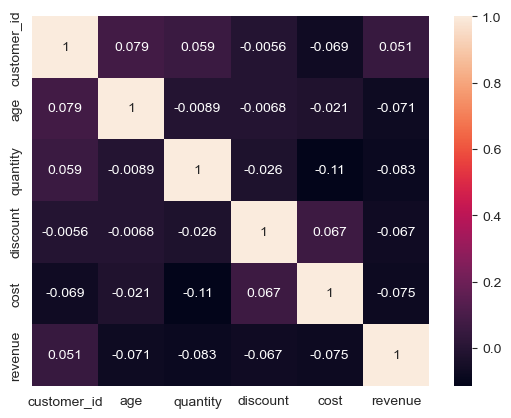

In [456]:
sns.heatmap(df.corr(numeric_only= True), annot=True)
plt.show()

In [457]:
#Revenue analysis
#revenue over time
df

,customer_id,gender,age,email,phone_number,address,city,state,zip_code,residence_type,...,quantity,unit_price,discount,cost,revenue,payment_method,card_type,shipping_address,shipping_method,delivery_status
0,4648,Female,30,lisa429@outlook.com,123-456-7890,8137 Pine Rd,Chicago,MI,96676,Lease,...,1.0,470.83,0.23,192.39,548.52,Paypal,Master,3253 Maple Ln,Overnight,Shipped
1,2537,Male,30,jane229@hotmail.com,123-456-7890,3575 Cedar Blvd,Phoenix,MI,95050,With Parents,...,1.0,196.44,0.06,180.84,767.34,Paypal,Amex,2073 Maple Ln,Express,Delivered
2,1466,Female,30,david860@outlook.com,997-600-8649,9792 Cedar Blvd,Philadelphia,GA,87456,With Parents,...,1.0,282.51,0.26,306.83,71.57,Paypal,Visa,4357 Cedar Blvd,Pickup,Pending
3,2224,Female,30,alex40@outlook.com,473-921-4406,5934 Cedar Blvd,Philadelphia,PA,58622,Own,...,3.0,274.05,0.03,297.11,64.83,Cc,Visa,8976 Cedar Blvd,Express,Shipped
4,5294,Female,66,emma243@outlook.com,123-456-7890,8485 Pine Rd,Phoenix,MI,72819,Lease,...,1.0,314.45,0.16,89.13,72.15,Dc,Visa,6738 Main St,Express,Delivered
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
342,4343,Female,74,emma83@gmail.com,589-506-8820,8552 Cedar Blvd,Chicago,GA,38566,Other,...,1.0,425.28,0.17,270.49,340.16,Cheque,Amex,9044 Pine Rd,Overnight,Delivered
343,2956,Male,37,jane586@gmail.com,123-456-7890,Unknown,San Diego,OH,31822,Other,...,1.0,291.47,0.13,187.01,415.68,Cash,Visa,5757 Main St,Express,Delivered
344,2807,Female,30,david400@hotmail.com,215-276-1984,5166 Pine Rd,San Diego,NC,89506,Rent,...,3.0,86.31,0.25,379.48,790.19,Paypal,Mastercard,475 Main St,Standard,Delivered
345,6023,Female,30,sarah148@hotmail.com,958-845-9119,610 Maple Ln,New York,PA,47916,Own,...,5.0,310.45,0.10,344.90,514.77,Paypal,Master,Same as billing,Express,Delivered


In [458]:
#creating transaction date columns
df["transaction_year"]=df["transaction_date"].dt.year
df["transaction_month"]=df["transaction_date"].dt.month

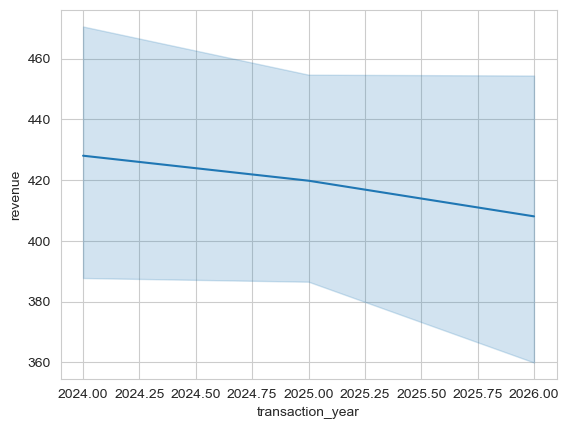

In [459]:
#revenue over time
sns.lineplot(x=df["transaction_year"], y=df["revenue"])
plt.show()

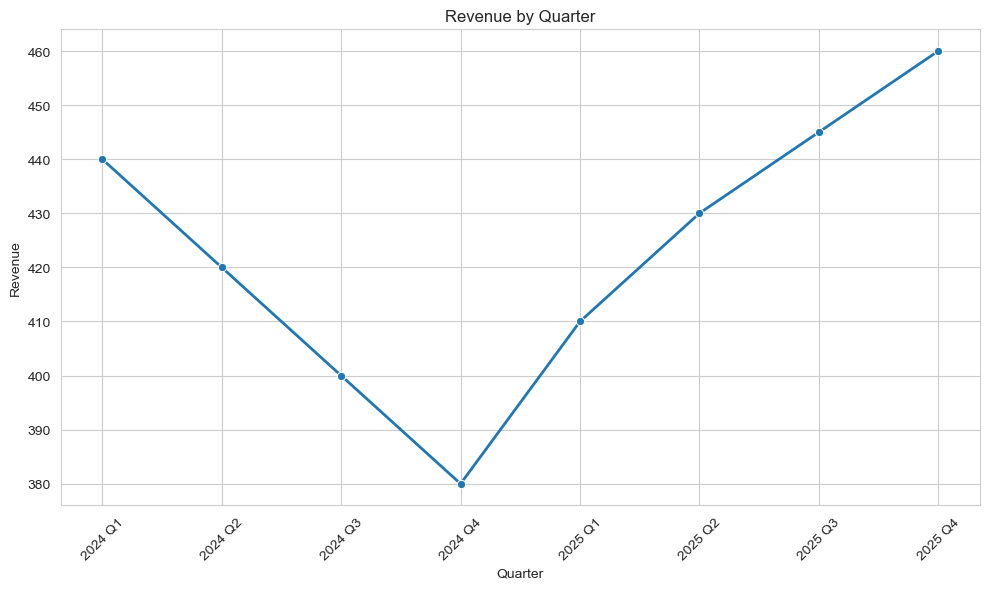

In [460]:
#revenue over time(transaction year)

# Sample data
df1 = pd.DataFrame({
    'transaction_year': [2024.00, 2024.25, 2024.50, 2024.75, 2025.00, 2025.25, 2025.50, 2025.75],
    'revenue': [440, 420, 400, 380, 410, 430, 445, 460]
})

# Create quarter labels
def decimal_to_quarter_label(decimal_year):
    year = int(decimal_year)
    quarter = int((decimal_year % 1) * 4) + 1
    return f'{year} Q{quarter}'

df1['quarter_label'] = df1['transaction_year'].apply(decimal_to_quarter_label)

# Plot with seaborn
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.lineplot(data=df1, x='transaction_year', y='revenue', marker='o', linewidth=2)

# Replace x-ticks with quarter labels
plt.xticks(
    ticks=df1['transaction_year'], 
    labels=df1['quarter_label'], 
    rotation=45
)

plt.xlabel('Quarter')
plt.ylabel('Revenue')
plt.title('Revenue by Quarter')
plt.tight_layout()
plt.show()

In [461]:
# barchart revenue by category
df["product_category"].unique()

array(['Clothing', 'Home', 'Electronics', 'Toys', 'Sports', 'Beauty',
       'Books'], dtype=object)

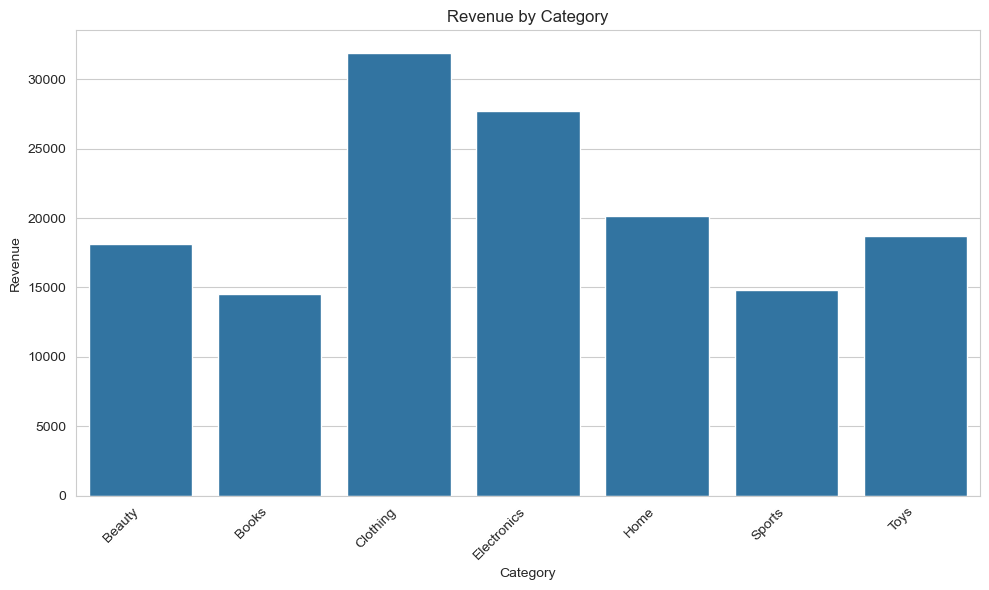

In [462]:
# Group by category and sum revenue
df2 = df.groupby('product_category')['revenue'].sum().reset_index()
df2.columns = ['category', 'revenue']  # Rename columns

# Then plot
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=df2, x='category', y='revenue')

plt.xlabel('Category')
plt.ylabel('Revenue')
plt.title('Revenue by Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [463]:
#bar chart of top 10 products
#group by product anf calculate total revenue
product_sales= df.groupby("product_category")["revenue"].sum().reset_index()

#sort and only keep top 10
top10_products= product_sales.sort_values(by="revenue", ascending=False).head(10)


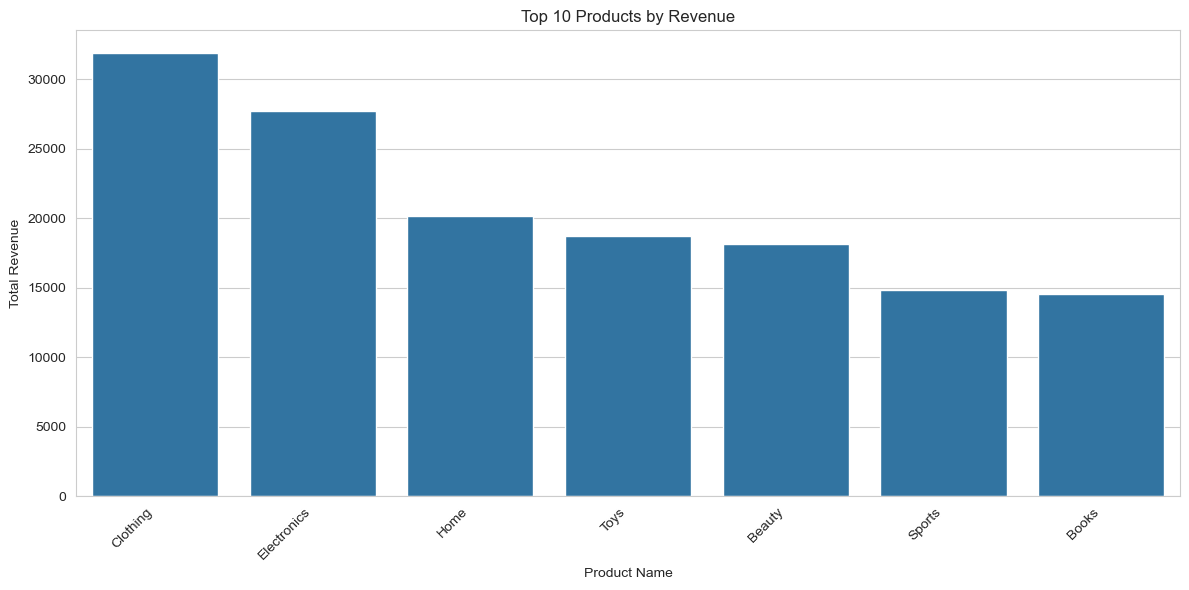

In [464]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(data=top10_products, x='product_category', y='revenue')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Product Name')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

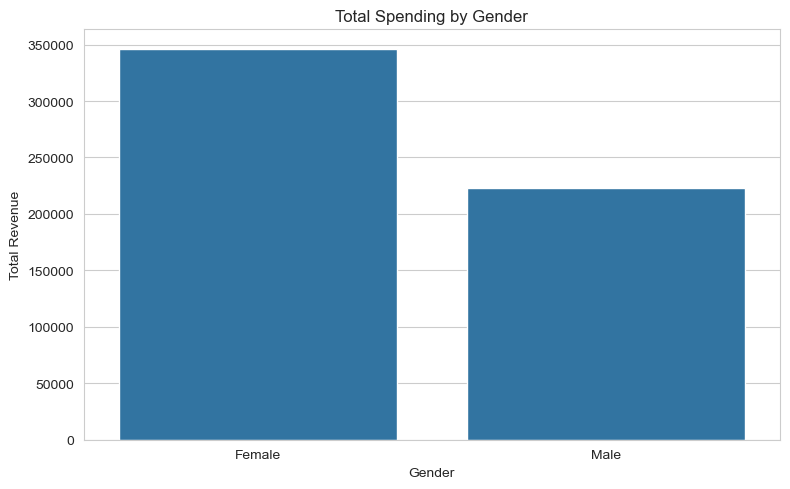

In [465]:
#total spending by gender
# calculate spending
df["unit_price"] = pd.to_numeric(df["unit_price"], errors="coerce")
df["spending_revenue"] = df["quantity"] * df["unit_price"]

# group by gender
gender_spending = df.groupby("gender")["spending_revenue"].sum().reset_index()

# create seaborn bar chart
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))   # FIXED

sns.barplot(data=gender_spending, x="gender", y="spending_revenue")

plt.title("Total Spending by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

In [466]:
#spending map by city
city_spending = df.groupby("state")["spending_revenue"].sum().reset_index()

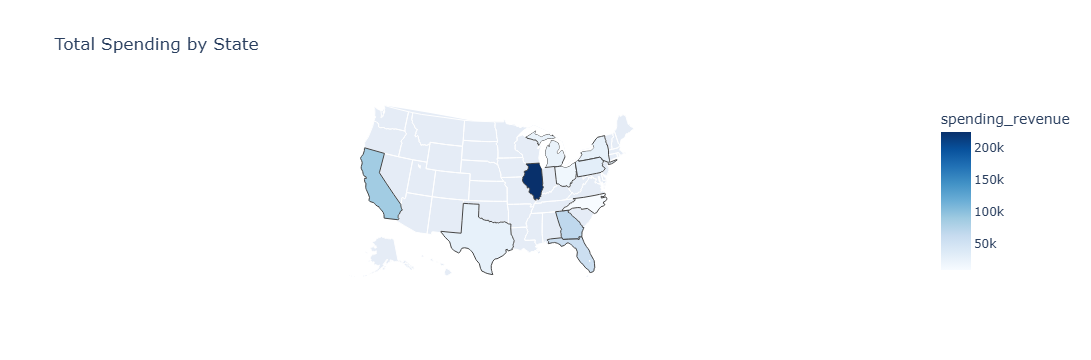

In [467]:
#map visualisation
import plotly.express as px

fig = px.choropleth(
    city_spending,
    locations="state",         # column with state abbreviations
    locationmode="USA-states",
    color="spending_revenue",           # spending amount
    scope="usa",
    color_continuous_scale="Blues",
    title="Total Spending by State"
)

fig.show()